In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


In [3]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


In [4]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


In [5]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


In [6]:
print(test_data.shape)
print(test_labels.shape)

(569, 64, 64, 3)
(569,)


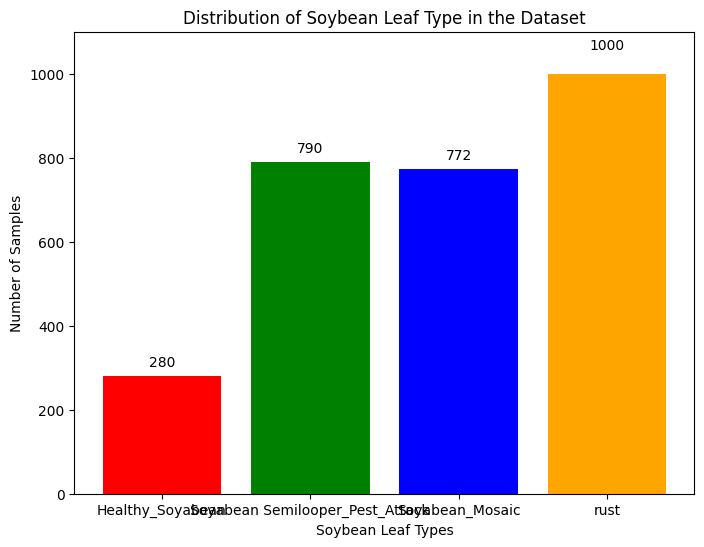

Data distribution plotted successfully.


In [7]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue', 'orange'])
plt.xlabel('Soybean Leaf Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Soybean Leaf Type in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

# EfficientNet B7

In [37]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

NUM_CLASSES = 4  # Change to your number of classes

base_model = EfficientNetB7(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

model.summary()
# # Unfreeze base model
# base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile after changing trainable status
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb7 (Functional)     │ (None, 2, 2, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │        10,244 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,107,931 (244.55 MB)

 Trainable params: 10,244 (40.02 KB)

 Non-trainable params: 64,097,687 (244.51 MB)

In [24]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.1747 - loss: 1.4734 - val_accuracy: 0.3533 - val_loss: 1.4004
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.3476 - loss: 1.3746 - val_accuracy: 0.3533 - val_loss: 1.3399
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3498 - loss: 1.3338 - val_accuracy: 0.3533 - val_loss: 1.3169
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3493 - loss: 1.3179 - val_accuracy: 0.3533 - val_loss: 1.3081
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3498 - loss: 1.3104 - val_accuracy: 0.3533 - val_loss: 1.3049
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3471 - loss: 1.3095 - val_accuracy: 0.3533 - val_loss: 1.3038
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3493 - loss: 1.3076 - val_accuracy: 0.3533 - val_loss: 1.3033
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3533 - loss: 1.3078 - val_accuracy: 0.3533 - v

In [38]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 247.24 MB


In [28]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

2026-07-22 07:09:00.054152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:09:00.190681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:09:00.437147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:09:00.573471: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:09:00.826943: E external/local_xla/xla/stream_

Inference Time : 63.051 ms/image
FPS            : 15.86


In [29]:
!pip install -q keras-flops

In [31]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784704279.917231      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784704279.917502      59 single_machine.cc:376] Starting new session
I0000 00:00:1784704279.933270      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784704279.935031      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

# ResNet 101

In [39]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained ResNet101
# =========================
base_model = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101 (Functional)          │ (None, 2, 2, 2048)     │    42,658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,666,372 (162.76 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 42,658,176 (162.73 MB)

In [33]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 306ms/step - accuracy: 0.3027 - loss: 1.3669 - val_accuracy: 0.2759 - val_loss: 1.3100
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3172 - loss: 1.3279 - val_accuracy: 0.3533 - val_loss: 1.2969
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3484 - loss: 1.3096 - val_accuracy: 0.3533 - val_loss: 1.2922
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3625 - loss: 1.3007 - val_accuracy: 0.3515 - val_loss: 1.2882
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3542 - loss: 1.2965 - val_accuracy: 0.3533 - val_loss: 1.2796
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3682 - loss: 1.2863 - val_accuracy: 0.3533 - val_loss: 1.2765
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3828 - loss: 1.2761 - val_accuracy: 0.3568 - val_loss: 1.2757
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3806 - loss: 1.2777 - val_accuracy: 0.4851 -

In [35]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 164.04 MB


In [34]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 22.502 ms/image
FPS            : 44.44


In [40]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784704552.268400      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784704552.268813      59 single_machine.cc:376] Starting new session
I0000 00:00:1784704552.284787      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784704552.286503      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

# ResNet 50

In [41]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained ResNet50
# =========================
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show architecture
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [42]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.2926 - loss: 1.3911 - val_accuracy: 0.3533 - val_loss: 1.3008
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3379 - loss: 1.3111 - val_accuracy: 0.3533 - val_loss: 1.2883
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3656 - loss: 1.2963 - val_accuracy: 0.3533 - val_loss: 1.2802
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3757 - loss: 1.2850 - val_accuracy: 0.3533 - val_loss: 1.2699
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3867 - loss: 1.2829 - val_accuracy: 0.3585 - val_loss: 1.2642
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4065 - loss: 1.2710 - val_accuracy: 0.4376 - val_loss: 1.2562
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4065 - loss: 1.2661 - val_accuracy: 0.4921 - val_loss: 1.2579
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4188 - loss: 1.2640 - val_accuracy: 0.4253 -

In [43]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 90.70 MB


In [44]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 12.927 ms/image
FPS            : 77.36


In [45]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784704735.693701      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784704735.693957      59 single_machine.cc:376] Starting new session
I0000 00:00:1784704735.709996      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784704735.711738      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

# VGG 19

In [46]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained VGG19
# =========================
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()



Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 2, 2, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,026,436 (76.39 MB)

 Trainable params: 2,052 (8.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [47]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.3722 - loss: 1.3542 - val_accuracy: 0.5255 - val_loss: 1.1742
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4527 - loss: 1.1672 - val_accuracy: 0.5975 - val_loss: 1.0567
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5482 - loss: 1.0683 - val_accuracy: 0.6924 - val_loss: 0.9684
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6111 - loss: 0.9737 - val_accuracy: 0.6960 - val_loss: 0.9048
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6590 - loss: 0.9200 - val_accuracy: 0.7469 - val_loss: 0.8517
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6942 - loss: 0.8635 - val_accuracy: 0.7047 - val_loss: 0.8155
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6947 - loss: 0.8271 - val_accuracy: 0.7417 - val_loss: 0.7712
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7008 - loss: 0.8029 - val_accuracy: 0.7557 - v

In [48]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 76.51 MB


In [50]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 1.042 ms/image
FPS            : 959.83


In [51]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784704831.520526      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784704831.520810      59 single_machine.cc:376] Starting new session
I0000 00:00:1784704831.536678      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784704831.538389      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


FLOPs : 3,186,767,896
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the 

# DenseNet 201

In [52]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained DenseNet201
# =========================
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()





Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 2, 2, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         7,684 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,329,668 (69.92 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [53]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6375 - loss: 0.9133 - val_accuracy: 0.8190 - val_loss: 0.5731
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8139 - loss: 0.5429 - val_accuracy: 0.8594 - val_loss: 0.4475
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8517 - loss: 0.4462 - val_accuracy: 0.8770 - val_loss: 0.3871
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8702 - loss: 0.3768 - val_accuracy: 0.8875 - val_loss: 0.3481
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8825 - loss: 0.3452 - val_accuracy: 0.8963 - val_loss: 0.3146
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8922 - loss: 0.3273 - val_accuracy: 0.9139 - val_loss: 0.2976
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9054 - loss: 0.2997 - val_accuracy: 0.9139 - val_loss: 0.2817
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8975 - loss: 0.3032 - val_accuracy: 0.9209 - v

In [54]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 72.36 MB


In [55]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 86.417 ms/image
FPS            : 11.57


In [56]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784705140.955533      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784705140.955857      59 single_machine.cc:376] Starting new session
I0000 00:00:1784705140.971689      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784705140.973384      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

# VGG 16

In [57]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained VGG16
# =========================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 2,052 (8.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [58]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.3432 - loss: 1.3655 - val_accuracy: 0.6169 - val_loss: 1.1807
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5073 - loss: 1.1552 - val_accuracy: 0.6239 - val_loss: 1.0528
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5772 - loss: 1.0471 - val_accuracy: 0.6503 - val_loss: 0.9712
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6282 - loss: 0.9608 - val_accuracy: 0.6608 - val_loss: 0.9013
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6502 - loss: 0.9029 - val_accuracy: 0.6907 - val_loss: 0.8511
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6788 - loss: 0.8579 - val_accuracy: 0.7065 - val_loss: 0.8129
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6841 - loss: 0.8185 - val_accuracy: 0.6995 - val_loss: 0.7811
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7158 - loss: 0.7776 - val_accuracy: 0.7311 - v

In [59]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 56.24 MB


In [61]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 1.028 ms/image
FPS            : 972.48


In [62]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784705337.343739      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784705337.344062      59 single_machine.cc:376] Starting new session
I0000 00:00:1784705337.360098      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784705337.361857      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


FLOPs : 2,507,184,152
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the 

# EfficientNet B0

In [63]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained EfficientNetB0
# =========================
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [64]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20


2026-07-22 07:30:43.097020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:30:43.229965: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:30:43.557200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:30:43.699421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:30:44.664276: E external/local_xla/xla/stream_

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3109 - loss: 1.3455

2026-07-22 07:31:02.402256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:31:02.537743: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.3111 - loss: 1.3453

2026-07-22 07:31:22.452878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:31:22.585462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:31:22.922412: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:31:23.064690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 07:31:23.956284: E external/local_xla/xla/stream_

72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 495ms/step - accuracy: 0.3168 - loss: 1.3372 - val_accuracy: 0.3533 - val_loss: 1.3074
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3168 - loss: 1.3341 - val_accuracy: 0.3533 - val_loss: 1.3345
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3273 - loss: 1.3400 - val_accuracy: 0.2742 - val_loss: 1.3185
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3093 - loss: 1.3464 - val_accuracy: 0.2759 - val_loss: 1.3202
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3370 - loss: 1.3343 - val_accuracy: 0.3533 - val_loss: 1.3036
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3154 - loss: 1.3458 - val_accuracy: 0.3533 - val_loss: 1.3112
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3264 - loss: 1.3297 - val_accuracy: 0.3533 - val_loss: 1.3100
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3176 - loss: 1.3302 - val_accuracy: 0.3533 - val_loss: 

In [72]:
import os
import tempfile

# Save model temporarily
temp_path = tempfile.NamedTemporaryFile(suffix=".keras", delete=False).name
model.save(temp_path)

# Calculate size
model_size_mb = os.path.getsize(temp_path) / (1024 ** 2)

print(f"Model Size: {model_size_mb:.2f} MB")

# Remove temporary file
os.remove(temp_path)

Model Size: 16.31 MB


In [73]:
import time

# Warm-up
_ = model.predict(test_data[:10], verbose=0)

start = time.perf_counter()

_ = model.predict(test_data, batch_size=32, verbose=0)

end = time.perf_counter()

total_time = end - start

ms_per_image = total_time / len(test_data) * 1000
fps = len(test_data) / total_time

print(f"Inference Time : {ms_per_image:.3f} ms/image")
print(f"FPS            : {fps:.2f}")

Inference Time : 0.602 ms/image
FPS            : 1662.25


In [74]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784705551.639842      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784705551.640218      59 single_machine.cc:376] Starting new session
I0000 00:00:1784705551.655662      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784705551.657374      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

# FPN-RF

In [8]:
# --- Simple FPN feature extractor (64x64x3 input) ---
def build_simple_fpn_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (your 3 conv blocks)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)  # C3 base
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)    # C4 base
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(c4)    # C5 base
    c5 = layers.MaxPooling2D(2)(x)   #  8x8x64

    # Lateral 1x1 to unify channels
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)  # 32x32xF
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)  # 16x16xF
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)  #  8x8xF

    # Top-down pathway (nearest upsample + add)
    p5 = l5
    p4 = layers.Add()([l4, layers.UpSampling2D(2)(p5)])      # 8->16
    p3 = layers.Add()([l3, layers.UpSampling2D(2)(p4)])      # 16->32

    # Light 3x3 refinement (optional but common in FPN)
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p3)
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)
    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p5)

    # Convert to one vector for SVM: GAP each level and concat
    g3 = layers.GlobalAveragePooling2D()(p3)   # -> (F,)
    g4 = layers.GlobalAveragePooling2D()(p4)   # -> (F,)
    g5 = layers.GlobalAveragePooling2D()(p5)   # -> (F,)
    feat_vec = layers.Concatenate(name="fpn_feat")([g3, g4, g5])  # -> (3F,)

    return models.Model(x_in, feat_vec, name="simple_fpn_feature_extractor")

# === Replace your previous model with this one ===
cnn_model = build_simple_fpn_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model.summary()

I0000 00:00:1784735540.864823      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784735540.868030      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "simple_fpn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        504 │ input_layer[0][0] │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      5,216 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │      4,160 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ conv2d_4[0][0],   │
│                     │ 64)               │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,216 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 142,488 (556.59 KB)

 Trainable params: 142,488 (556.59 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Feature extraction (same usage pattern as your code)
train_features = cnn_model.predict(train_data, batch_size=64, verbose=0)
test_features  = cnn_model.predict(test_data,  batch_size=64, verbose=0)

# (Optional) L2 normalization helps SVMs
def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features = l2_normalize(train_features)
test_features  = l2_normalize(test_features)

# If you still want to "flatten" like before, it's already 2D (N, 3*fpn_channels).
# But this keeps compatibility with your original lines:
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flattened  = np.reshape(test_features,  (test_features.shape[0], -1))

I0000 00:00:1784735545.138897     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


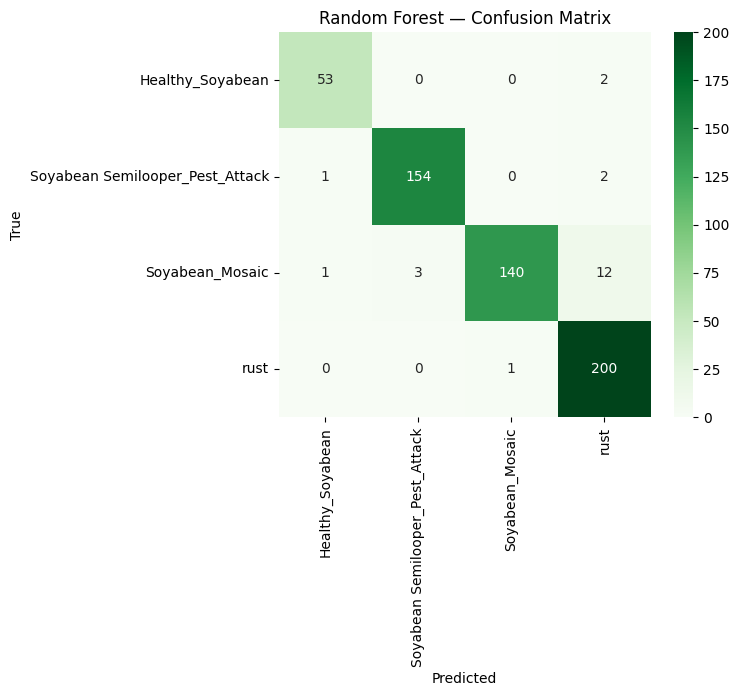

Random Forest — Classification Report
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9636    0.9636    0.9636        55
Soyabean Semilooper_Pest_Attack     0.9809    0.9809    0.9809       157
                Soyabean_Mosaic     0.9929    0.8974    0.9428       156
                           rust     0.9259    0.9950    0.9592       201

                       accuracy                         0.9613       569
                      macro avg     0.9658    0.9592    0.9616       569
                   weighted avg     0.9631    0.9613    0.9611       569



In [17]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,           
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",      
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1
)
rf_model.fit(train_features_flattened, train_labels)

rf_pred_labels = rf_model.predict(test_features_flattened)
rf_pred_probs  = rf_model.predict_proba(test_features_flattened)

rf_cm = confusion_matrix(test_labels, rf_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest — Confusion Matrix")
plt.show()

# 🧾 Report
print("Random Forest — Classification Report\n",
      classification_report(test_labels, rf_pred_labels, target_names=label_encoder.classes_,digits=4))

In [20]:
import os
import joblib
import tempfile
import tensorflow as tf

# Save FPN feature extractor
fpn_path = tempfile.NamedTemporaryFile(
    suffix=".keras",
    delete=False
).name

cnn_model.save(fpn_path)

# Save RF classifier
rf_path = tempfile.NamedTemporaryFile(
    suffix=".pkl",
    delete=False
).name

joblib.dump(rf_model, rf_path)

# Calculate sizes
fpn_size_kb = os.path.getsize(fpn_path) / 1024
rf_size_kb = os.path.getsize(rf_path) / 1024
total_size_kb = fpn_size_kb + rf_size_kb

fpn_size_mb = fpn_size_kb / 1024
rf_size_mb = rf_size_kb / 1024
total_size_mb = total_size_kb / 1024

# Print results
print(f"FPN Size      : {fpn_size_kb:.2f} KB ({fpn_size_mb:.2f} MB)")
print(f"RF Size       : {rf_size_kb:.2f} KB ({rf_size_mb:.2f} MB)")
print(f"Total Size    : {total_size_kb:.2f} KB ({total_size_mb:.2f} MB)")

# Cleanup
os.remove(fpn_path)
os.remove(rf_path)

FPN Size      : 627.90 KB (0.61 MB)
RF Size       : 8474.52 KB (8.28 MB)
Total Size    : 9102.42 KB (8.89 MB)


In [363]:
import time
import numpy as np

# Warm-up run
_ = cnn_model.predict(test_data[:20], batch_size=64, verbose=0)

# Start timing
start_time = time.perf_counter()

# Feature extraction
features = cnn_model.predict(test_data, batch_size=64, verbose=0)

# Flatten features
features_flat = features.reshape(features.shape[0], -1)

# RF prediction
predictions = rf_model.predict(features_flat)

# End timing
end_time = time.perf_counter()

# Metrics
num_images = len(test_data)
total_time = end_time - start_time

inference_time_per_image = total_time / num_images
fps = num_images / total_time

print(f"Total Images           : {num_images}")
print(f"Total Inference Time   : {total_time:.6f} sec")
print(f"Inference Time/Image   : {inference_time_per_image*1000:.3f} ms")
print(f"FPS                    : {fps:.2f}")

Total Images           : 569
Total Inference Time   : 0.383129 sec
Inference Time/Image   : 0.673 ms
FPS                    : 1485.14


In [124]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1, 64, 64, 3], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)

print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.2f}")
print(f"GFLOPs: {flops/1e9:.4f}")

I0000 00:00:1784706844.100012      59 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784706844.100261      59 single_machine.cc:376] Starting new session
I0000 00:00:1784706844.117638      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784706844.119305      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th